# Lab 04 : One-Step Actor-Critic (QAC) - demo

This notebook provides a demonstration of the One-Step Actor-Critic (QAC) algorithm applied to the CartPole-v0 environment. It combines policy-based and value-based reinforcement learning methods to optimize balancing performance.

Actor-Critic Architecture: Defines an ActorCritic_NN class that houses two distinct networks: an Actor (policy network) to select actions and a Critic (Q-network) to estimate state-action values (Q-values).

Hybrid Loss Function: Implements a dual-objective loss. The policy loss uses the Critic's Q-value estimates to scale gradients, while the Critic loss is calculated using Temporal Difference (TD) errors via a Mean Squared Error (MSE) objective.

Action Selection: Uses stochastic Bernoulli sampling based on the Actor's output probabilities to encourage exploration during training.

Training and Performance: The model iteratively improves through episode rollouts, reaching a high reward threshold (400 steps) within approximately 50 epochs.


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    !pip install 'gymnasium[classic_control]' 
    !pip install gym-notebook-wrapper
    

In [2]:
import torch
import torch.nn as nn
torch.manual_seed(torch.randint(10000,())) # random seed for pythorch random generator
import time
import numpy as np
import os
import pickle
import gymnasium as gym 
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from collections import namedtuple
import random
from itertools import count
class DotDict(dict):
    def __init__(self, **kwds):
        self.update(kwds)
        self.__dict__ = self
        

# Dataset

In [3]:
#Initialize the environment with the same seed/initialization value
env = gym.make('CartPole-v1')

# Reset the environment
state, info = env.reset() # initial state from the environment
print('init state:',state)

# Rollout one episode until it finishes 
for t in count():  
    action = torch.LongTensor(1).random_(0,2).item() # randomly generated action=a in {0,1}
    state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
    done = terminated or truncated
    print('t=',t, 'action=',action, 'state=',np.array_str(state, precision=5), 'reward=',reward, 'done=',done )
    if done:
        break


init state: [ 0.02790043 -0.02014373 -0.01539463  0.04005324]
t= 0 action= 0 state= [ 0.0275  -0.21504 -0.01459  0.32784] reward= 1.0 done= False
t= 1 action= 0 state= [ 0.0232  -0.40995 -0.00804  0.61588] reward= 1.0 done= False
t= 2 action= 1 state= [ 0.015   -0.21472  0.00428  0.32068] reward= 1.0 done= False
t= 3 action= 0 state= [ 0.0107  -0.4099   0.01069  0.61471] reward= 1.0 done= False
t= 4 action= 1 state= [ 0.00251 -0.21493  0.02299  0.32542] reward= 1.0 done= False
t= 5 action= 0 state= [-0.00179 -0.41037  0.0295   0.62526] reward= 1.0 done= False
t= 6 action= 0 state= [-0.01    -0.60589  0.042    0.92708] reward= 1.0 done= False
t= 7 action= 0 state= [-0.02212 -0.80156  0.06054  1.23266] reward= 1.0 done= False
t= 8 action= 1 state= [-0.03815 -0.60726  0.0852   0.95955] reward= 1.0 done= False
t= 9 action= 0 state= [-0.0503  -0.80342  0.10439  1.27773] reward= 1.0 done= False
t= 10 action= 0 state= [-0.06636 -0.99971  0.12994  1.6012 ] reward= 1.0 done= False
t= 11 action=

# Define the policy network

In [4]:
# class of policy network
class ActorCritic_NN(nn.Module): 
    
    def __init__(self, net_parameters):
        super(ActorCritic_NN, self).__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        # policy network
        self.fc1_p = nn.Linear(input_dim, hidden_dim)
        self.fc2_p = nn.Linear(hidden_dim, output_dim)
        # state-value function network
        self.fc1_q = nn.Linear(input_dim, hidden_dim)
        self.fc2_q = nn.Linear(hidden_dim, output_dim)

    def forward_policy(self, x):
        x = torch.relu(self.fc1_p(x))
        actions_score = self.fc2_p(x)
        actions_prob = torch.softmax(actions_score, dim=1)
        return actions_prob
    
    def forward_Q(self, x):
        x = torch.relu(self.fc1_q(x))
        Q_scores = self.fc2_q(x) # scores over actions 
        return Q_scores
    
    def select_action(self, state): # select action w/ policy network
        probs = actorcritic_net.forward_policy(state) # probability of action a in state s
        bernoulli_sampling = torch.distributions.Categorical(probs) 
        action = bernoulli_sampling.sample() # sample action a with Bernoulli sampling
        return action

    def loss(self, batch):
        gamma = opt_parameters['gamma']
        nb_episodes_per_batch = len(batch.states)
        batch_losses = []
        for episode in range(nb_episodes_per_batch):
            episode_states = torch.stack( batch.states[episode] ).float() #size=B x 4     
            episode_next_states = torch.stack( batch.next_states[episode] ).float() #size=B x 4  
            episode_actions = torch.stack( batch.actions[episode] ).long() #size=B
            episode_rewards = - torch.stack( batch.rewards[episode] ).float() #size=B
            episode_dones = torch.stack( batch.dones[episode] ).float() #size=B
            R = 0; policy_loss = []; rewards = []
            for r in batch.rewards[episode][::-1]: # compute the discarded award at each time step
                R = r + gamma * R
                rewards.insert(0, R)
            episode_discounted_rewards = torch.tensor(rewards).float() #size=B
            episode_next_actions = self.select_action(episode_next_states) #size=B
            Q = self.forward_Q(episode_states).gather(dim=1,index=episode_actions.unsqueeze(1)) # Qv(a|s), size=B x 1
            Q_target = episode_rewards.unsqueeze(1) + gamma *  \
                self.forward_Q(episode_next_states).gather(dim=1,index=episode_next_actions.unsqueeze(1)) * episode_dones.unsqueeze(1)
            logP = torch.log( actorcritic_net.forward_policy(episode_states).gather(dim=1,index=episode_actions.unsqueeze(1)) )
            loss1 = ( -logP * Q.detach() ).mean()
            loss2 = nn.MSELoss()(Q,Q_target.detach())
            loss = loss1 + loss2
            batch_losses.append(loss)
        loss = torch.stack(batch_losses).mean()
        return loss

        
# class of rollout episodes    
def rollout_batch_episodes(env, opt_parameters, actorcritic_net, write_memory=True):
    # storage structure of all episodes (w/ different lengths)
    nb_episodes_per_batch = opt_parameters['nb_episodes_per_batch']
    env_seeds = opt_parameters['env_seed']
    batch = DotDict()
    batch.states = []
    batch.actions = []
    batch.next_states = []
    batch.rewards = []
    batch.dones = []
    batch_episode_lengths = []
    for episode in range(nb_episodes_per_batch):
        states = []
        actions = []
        next_states = []
        rewards = []
        dones = []
        state, info = env.reset(seed=int(env_seeds[episode].item())) # start with random seed
        for t in range(1000): # rollout one episode 
            state_pytorch = torch.from_numpy(state).float().unsqueeze(0) # state=s
            action = actorcritic_net.select_action(state_pytorch).item() # select action=a from state=s
            next_state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
            done = terminated or truncated
            done_mask = 0.0 if done else 1.0
            states.append(torch.tensor(state))
            actions.append(torch.tensor(action))
            next_states.append(torch.tensor(next_state))
            rewards.append(torch.tensor(reward))
            dones.append(torch.tensor(done_mask))
            state = next_state
            if done:
                batch_episode_lengths.append(t)
                break
        batch.states.append(states)
        batch.actions.append(actions)
        batch.next_states.append(next_states)
        batch.rewards.append(rewards)
        batch.dones.append(dones)
    return batch_episode_lengths, batch

        
    
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 2

# instantiate network
actorcritic_net = ActorCritic_NN(net_parameters)
print(actorcritic_net)

# optimization parameters
opt_parameters = {}
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)

env = gym.make('CartPole-v1')

batch_episode_lengths, batch = rollout_batch_episodes(env, opt_parameters, actorcritic_net)
#print('batch:',batch)
print('batch_episode_lengths:',batch_episode_lengths)


ActorCritic_NN(
  (fc1_p): Linear(in_features=4, out_features=128, bias=True)
  (fc2_p): Linear(in_features=128, out_features=2, bias=True)
  (fc1_q): Linear(in_features=4, out_features=128, bias=True)
  (fc2_q): Linear(in_features=128, out_features=2, bias=True)
)
batch_episode_lengths: [12, 16, 25]


# Test forward pass

In [5]:
# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.001
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['gamma'] = 0.99

batch_episode_lengths, batch = rollout_batch_episodes(env, opt_parameters, actorcritic_net)
#print('batch:',batch)
print('batch_episode_lengths:',batch_episode_lengths)


batch_episode_lengths: [12, 18, 13]


# Test backward pass

In [6]:
# Loss
loss = actorcritic_net.loss(batch)
print('loss:',loss)

# Backward pass
lr = opt_parameters['lr']
optimizer = torch.optim.Adam(actorcritic_net.parameters(), lr=lr)
optimizer.zero_grad()
loss.backward()
optimizer.step()


loss: tensor(0.9070, grad_fn=<MeanBackward0>)


# Train one epoch

In [7]:
def train_one_epoch(env, actorcritic_net, opt_parameters):
    """
    train one epoch
    """
    actorcritic_net.train()
    epoch_loss = 0
    nb_data = 0
    epoch_episode_length = 0
    epoch_episode_lengths = []
    nb_batches_per_epoch = opt_parameters['nb_batches_per_epoch']
    for iter in range(nb_batches_per_epoch):
        batch_episode_lengths, batch = rollout_batch_episodes(env, opt_parameters, actorcritic_net)
        loss = actorcritic_net.loss(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach().item()
        nb_data += len(batch_episode_lengths)
        epoch_episode_length += torch.tensor(batch_episode_lengths).float().sum()
        epoch_episode_lengths.append(epoch_episode_length)
    epoch_loss /= nb_data
    epoch_episode_length /= nb_data
    return epoch_loss, epoch_episode_length, epoch_episode_lengths



# Train NN

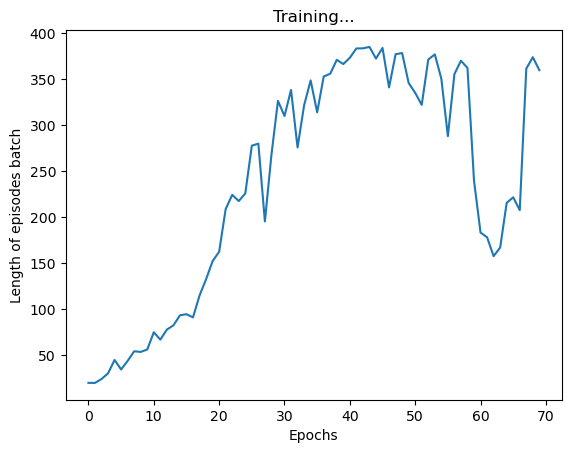

Training done.
Last episode length is 398.6199951171875, epoch is 73


In [8]:
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 256
net_parameters['output_dim'] = 2

# instantiate network
actorcritic_net = ActorCritic_NN(net_parameters)
print(actorcritic_net)

# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.0005
opt_parameters['nb_episodes_per_batch'] = 1
opt_parameters['nb_batches_per_epoch'] = 50
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['gamma'] = 0.99

optimizer = torch.optim.Adam(actorcritic_net.parameters(), lr=opt_parameters['lr'] )

# select maximum episode length to learn
env = gym.make('CartPole-v1')
env._max_episode_steps = 400 # 200 400
env.spec.reward_threshold = 0.975* env._max_episode_steps
print('env._max_episode_steps',env._max_episode_steps)

# train loop
all_epoch_lengths = []
start = time.time()
num_epochs = 500
for epoch in range(num_epochs): 
    
    # train one epoch
    epoch_train_loss, epoch_episode_length, epoch_episode_lengths = train_one_epoch(env, actorcritic_net, opt_parameters)
 
    # stop training when reward is high
    if epoch_episode_length > env.spec.reward_threshold:
        print('Training done.')
        print("Last episode length is {}, epoch is {}".
              format(epoch_episode_length, epoch))
        break

    # print intermediate info
    if not (epoch+1)%10:
        print('Epoch: {}, time: {:.4f}, train_loss: {:.4f}, episode_length: {:.4f}'.format(epoch, time.time()-start, epoch_train_loss, epoch_episode_length))
        
    # plot all epochs
    all_epoch_lengths.append(epoch_episode_length)
    if not (epoch+1)%10:
        if epoch<num_epochs:
            display.clear_output(wait=True)
        plt.figure(2)
        plt.title('Training...')
        plt.xlabel('Epochs')
        plt.ylabel('Length of episodes batch')
        plt.plot(torch.Tensor(all_epoch_lengths).numpy())
        plt.pause(0.001)


# Visualize

Finished at step 299


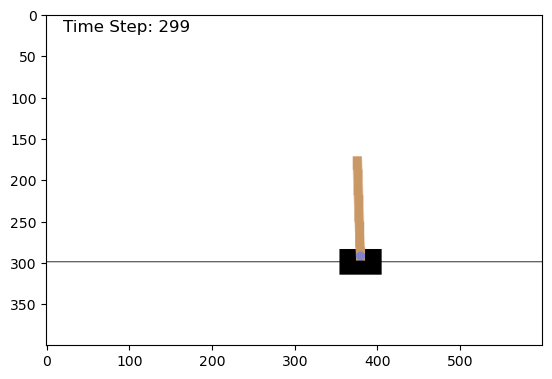

In [10]:
# For Google Colaboratory
import sys
if 'google.colab' in sys.modules:
    import gnwrapper
    env = gnwrapper.Monitor(gym.make('CartPole-v1', render_mode="rgb_array"), directory="./") 
    env._max_episode_steps = 300
    state, _ = env.reset()
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = actorcritic_net.eval().select_action(state_pytorch).item() # select action=a from state=s 
        state, reward, terminated, truncated = env.step(action) # collab
        done = terminated or truncated
        # env.render() # no need this line with Monitor/gnwrapper; it records automatically
        if done:
            print(f"Episode finished at step {t}")
            break
    env.display()

# For Local Environment
else: 
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env._max_episode_steps = 300
    state, info = env.reset() 
    img = plt.imshow(env.render()) # Setup the plot
    time_text = plt.text(20, 20, '', color='black', fontsize=12)
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = actorcritic_net.eval().select_action(state_pytorch).item() # select action=a from state=s     
        state, reward, terminated, truncated, info = env.step(action) # cpu
        done = terminated or truncated
        img.set_data(env.render()) 
        time_text.set_text(f'Time Step: {t}')
        display.display(plt.gcf())
        display.clear_output(wait=True)
        if done:
            break
        env.close()
    print(f"Finished at step {t}")

        